# Анализ работы модели на валидационной выборке

Этот ноутбук предназначен для:
- Загрузки обученной модели
- Анализа качества реконструкции на случайной валидационной выборке
- Визуализации результатов
- Анализа ошибок по высотам

In [2]:
cd ..

/home/jupyter-polyakov1337_2026/science/co_autoencoder_project


/opt/tljh/user/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path

# Добавляем src в path
sys.path.insert(0, 'src')

# Импорты
from src.models import Conv3DAutoencoder, SimpleConv3DAutoencoder
from src.data import load_data, normalize_data, ConcentrationFieldDataset
from src.train import WeightedHeightLoss, Trainer, load_model
from sklearn.model_selection import train_test_split

%matplotlib inline

## Загрузка модели

In [7]:
# Путь к модели
MODEL_PATH = 'models/best_model.pth'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Загружаем модель
model, checkpoint = load_model(MODEL_PATH, Conv3DAutoencoder, device=DEVICE)

print(f"\nИнформация о модели:")
print(f"  Лучший Val Loss: {checkpoint.get('best_val_loss', 'N/A')}")
print(f"  Лучший Val MSE: {checkpoint.get('best_val_mse', 'N/A')}")

✓ Модель загружена из models/best_model.pth
  Best Val Loss: 0.008629680797457694
  Best Val MSE: 0.007014723028987646

Информация о модели:
  Лучший Val Loss: 0.008629680797457694
  Лучший Val MSE: 0.007014723028987646


## Загрузка всех данных и создание валидационной выборки

**Важно:** Используем те же параметры разбиения, что и при обучении (random_state=42, val_split=0.10)

In [8]:
# Список всех файлов (как в config.yaml)
ALL_FILES = [
    '../OUTPUT/Nsk_2024-07-01_00_00_to_2024-07-02_00_00/all_sources/uvwmn_d03_2024-07-01_00:00:00_n33_chem_13.nc',
    '../OUTPUT/Nsk_2024-07-13_00_00_to_2024-07-14_00_00/all_sources/uvwmn_d03_2024-07-13_00:00:00_n33_chem_13.nc',
    '../OUTPUT/Nsk_2024-07-28_00_00_to_2024-07-29_00_00/all_sources/uvwmn_d03_2024-07-28_00:00:00_n33_chem_13.nc',
    '../OUTPUT/Nsk_2024-08-05_00_00_to_2024-08-06_00_00/all_sources/uvwmn_d03_2024-08-05_00:00:00_n33_chem_13.nc',
    '../OUTPUT/Nsk_2024-08-26_00_00_to_2024-08-27_00_00/all_sources/uvwmn_d03_2024-08-26_00:00:00_n33_chem_13.nc',
    '../OUTPUT/Nsk_2024-09-05_00_00_to_2024-09-06_00_00/all_sources/uvwmn_d03_2024-09-05_00:00:00_n33_chem_13.nc',
    '../OUTPUT/Nsk_2024-09-12_00_00_to_2024-09-13_00_00/all_sources/uvwmn_d03_2024-09-12_00:00:00_n33_chem_13.nc',
    '../OUTPUT/Nsk_2025-04-29_00_00_to_2025-04-30_00_00/all_sources/uvwmn_d03_2025-04-29_00:00:00_n33_chem_13.nc',
    '../OUTPUT/Nsk_2025-05-09_00_00_to_2025-05-10_00_00/all_sources/uvwmn_d03_2025-05-09_00:00:00_n33_chem_13.nc',
    '../OUTPUT/Nsk_2025-05-15_00_00_to_2025-05-16_00_00/all_sources/uvwmn_d03_2025-05-15_00:00:00_n33_chem_13.nc',
    '../OUTPUT/Nsk_2025-06-18_00_00_to_2025-06-19_00_00/all_sources/uvwmn_d03_2025-06-18_00:00:00_n33_chem_13.nc',
]

# Параметры (должны совпадать с config.yaml)
VAL_SPLIT = 0.10
RANDOM_SEED = 42

# Загружаем все данные
print("Загрузка всех данных...")
all_data = load_data(ALL_FILES, base_dir='')
all_normalized = normalize_data(all_data)

print(f"\nВсего кадров: {len(all_normalized)}")

# Случайное разбиение (как при обучении!)
indices = list(range(len(all_normalized)))
train_indices, val_indices = train_test_split(
    indices, 
    test_size=VAL_SPLIT, 
    random_state=RANDOM_SEED
)

full_dataset = ConcentrationFieldDataset(all_normalized)
val_dataset = torch.utils.data.Subset(full_dataset, val_indices)

print(f"\nВалидационная выборка: {len(val_dataset)} кадров ({len(val_indices)/len(indices)*100:.1f}%)")
print(f"random_state={RANDOM_SEED}, val_split={VAL_SPLIT}")

Загрузка всех данных...


Загрузка файлов: 100%|██████████| 11/11 [00:06<00:00,  1.74it/s]


Объединенные данные: (1595, 32, 96, 84)
Нормализованные данные: min=0.0000, max=1.0000

Всего кадров: 1595

Валидационная выборка: 160 кадров (10.0%)
random_state=42, val_split=0.1


## Детальная визуализация реконструкции по высотам

Сравнение оригинала и реконструкции для разных высотных уровней

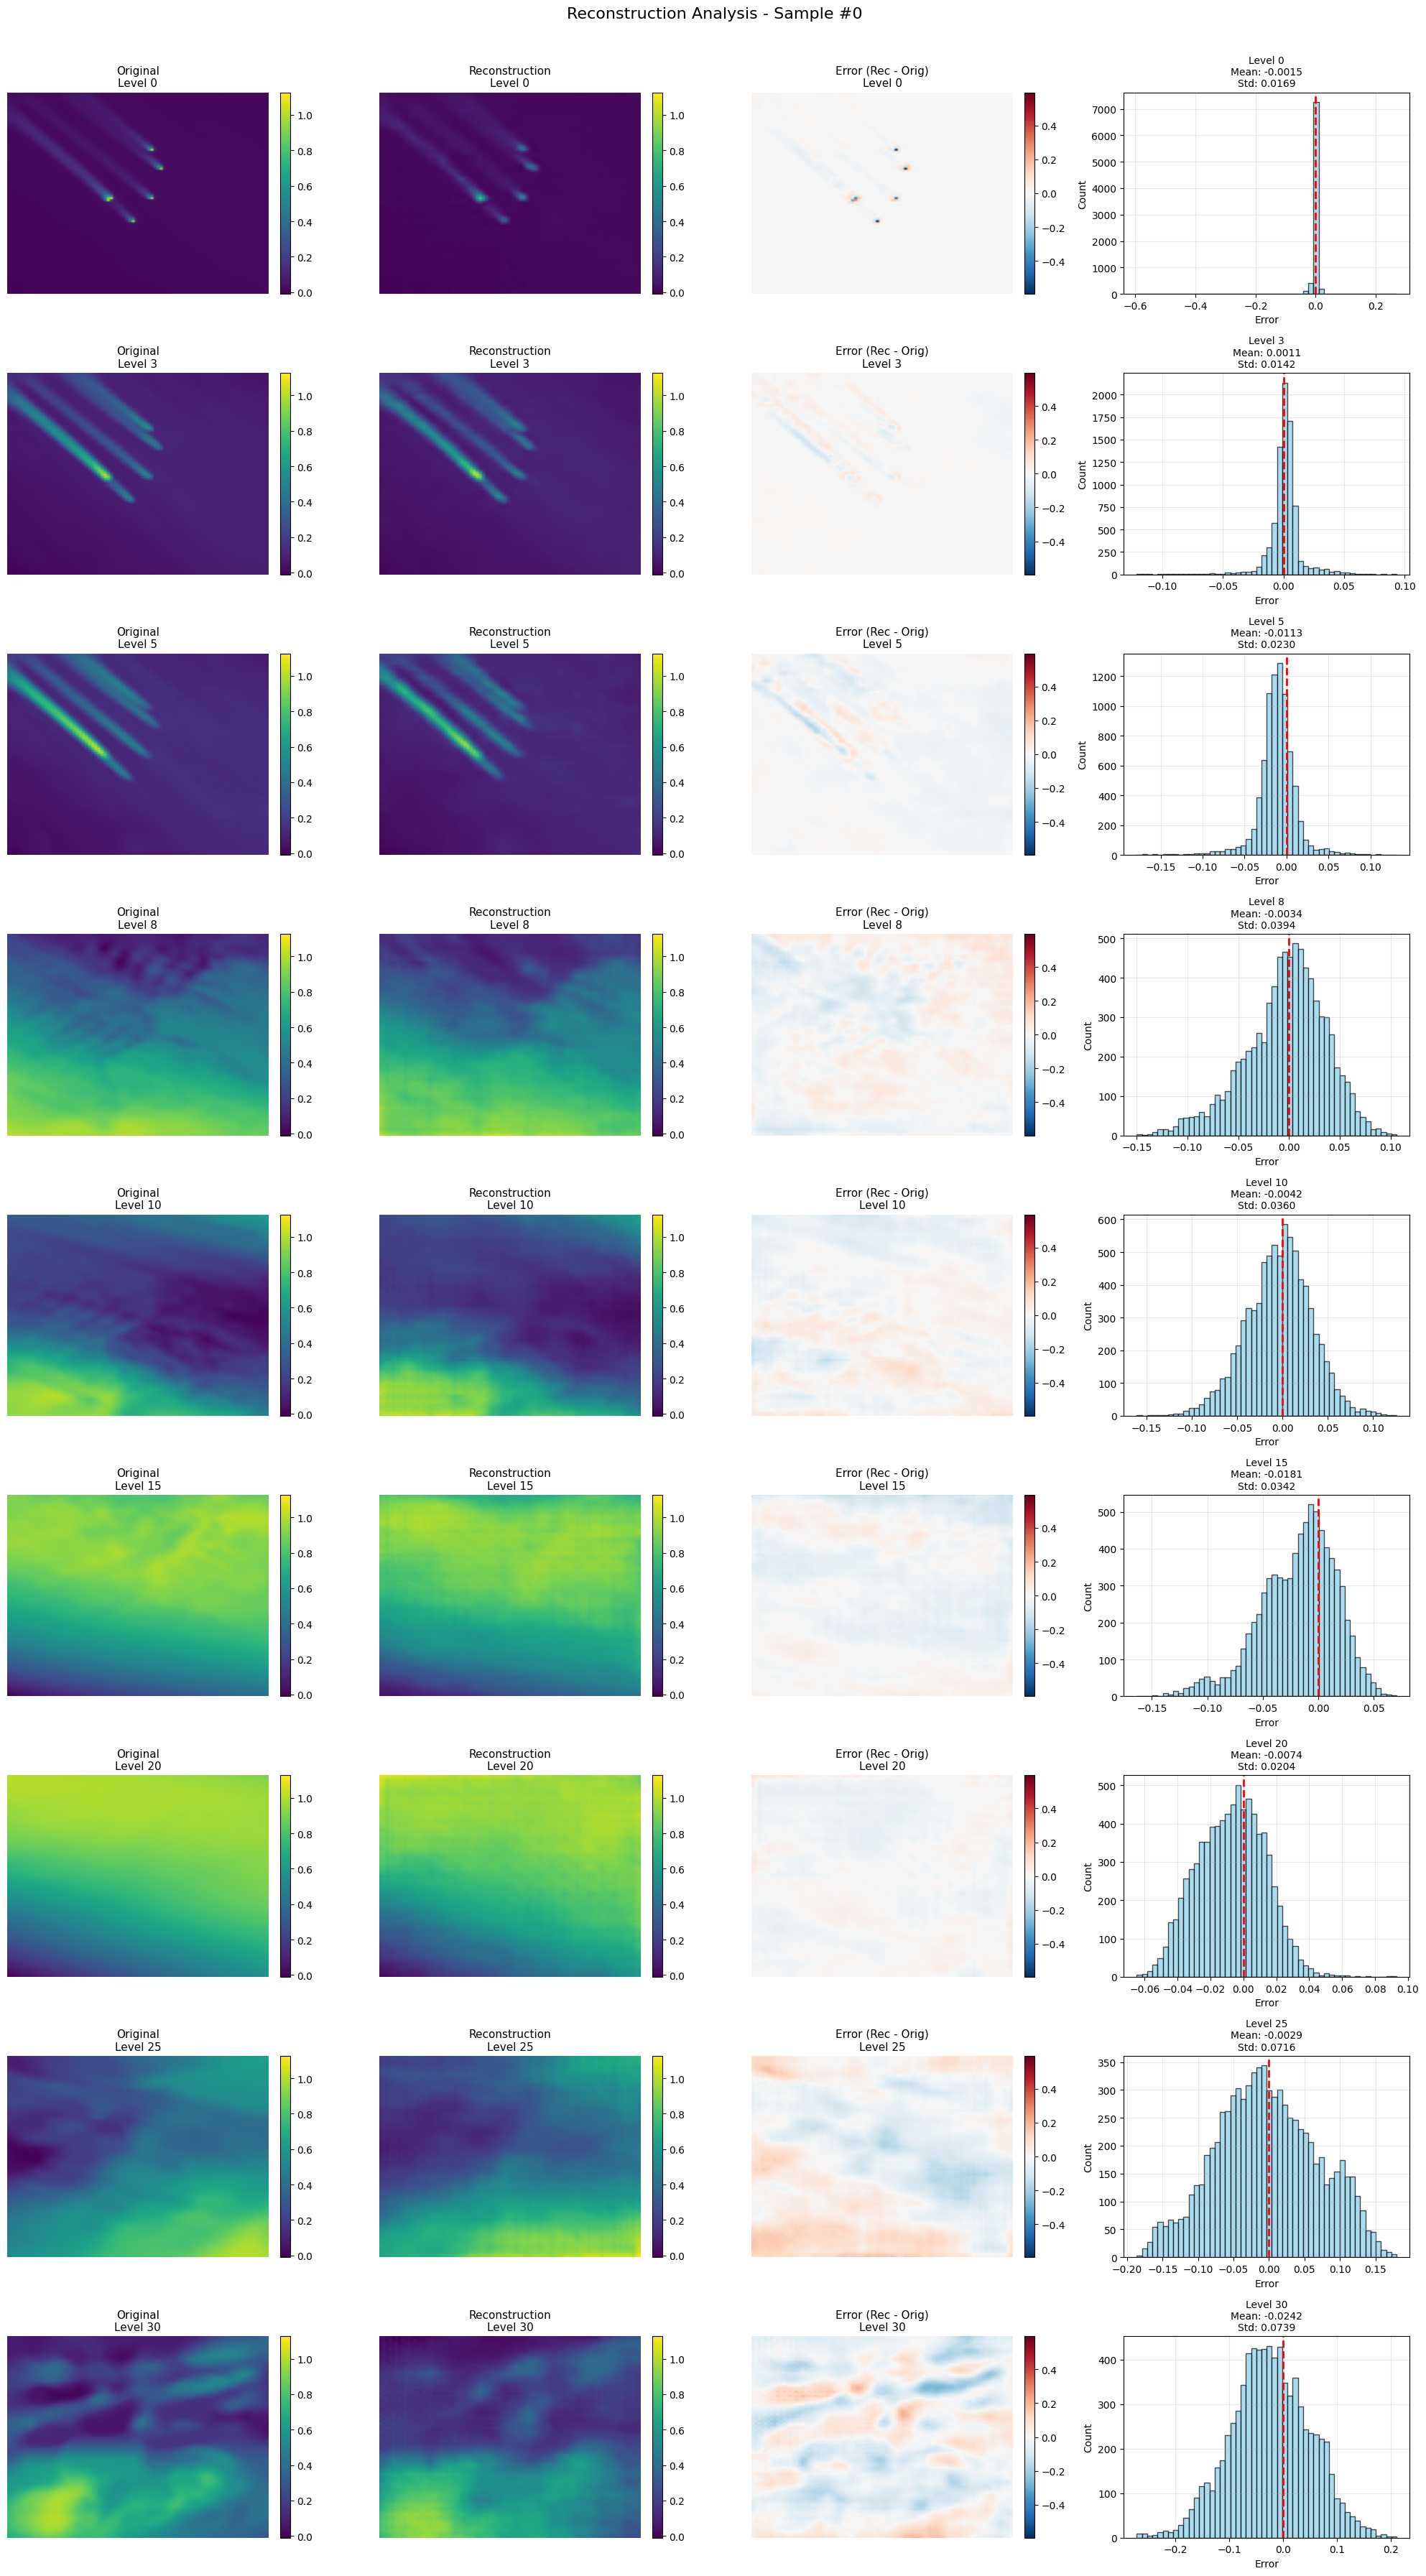

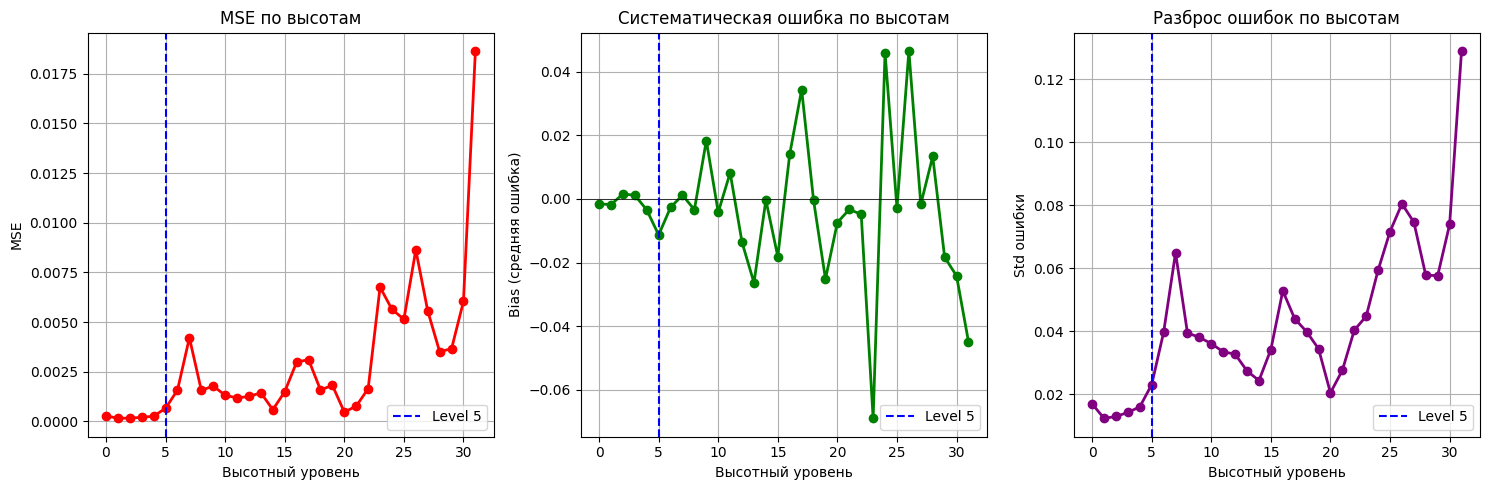

In [9]:
def plot_height_comparison(model, dataset, sample_idx=0, levels=None, device='cpu'):
    """
    Детальное сравнение оригинала и реконструкции по высотам
    
    Args:
        model: обученная модель
        dataset: валидационный датасет
        sample_idx: индекс сэмпла для визуализации
        levels: список высотных уровней для отображения
        device: устройство
    """
    if levels is None:
        levels = [0, 3, 5, 8, 10, 15, 20, 25, 30]
    
    model.eval()
    
    with torch.no_grad():
        sample = dataset[sample_idx].unsqueeze(0).to(device)
        reconstructed, _ = model(sample)
        
        original = sample.cpu().numpy()[0, 0]  # (32, 96, 84)
        recon = reconstructed.cpu().numpy()[0, 0]
        error = recon - original
    
    # Определяем количество рядов и колонок
    n_levels = len(levels)
    n_cols = 4  # Original, Reconstruction, Error, Error Profile
    
    fig = plt.figure(figsize=(20, 4*n_levels))
    
    # Общий colorbar для оригинала и реконструкции
    vmin = min(original.min(), recon.min())
    vmax = max(original.max(), recon.max())
    
    # Colorbar для ошибки
    err_max = max(abs(error.min()), abs(error.max()))
    
    for i, level in enumerate(levels):
        if level >= original.shape[0]:
            continue
        
        # Original
        ax1 = plt.subplot(n_levels, n_cols, i*n_cols + 1)
        im1 = ax1.imshow(original[level], cmap='viridis', aspect='auto', vmin=vmin, vmax=vmax)
        ax1.set_title(f'Original\nLevel {level}', fontsize=11)
        ax1.axis('off')
        plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
        
        # Reconstruction
        ax2 = plt.subplot(n_levels, n_cols, i*n_cols + 2)
        im2 = ax2.imshow(recon[level], cmap='viridis', aspect='auto', vmin=vmin, vmax=vmax)
        ax2.set_title(f'Reconstruction\nLevel {level}', fontsize=11)
        ax2.axis('off')
        plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
        
        # Error
        ax3 = plt.subplot(n_levels, n_cols, i*n_cols + 3)
        im3 = ax3.imshow(error[level], cmap='RdBu_r', aspect='auto', vmin=-err_max, vmax=err_max)
        ax3.set_title(f'Error (Rec - Orig)\nLevel {level}', fontsize=11)
        ax3.axis('off')
        plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)
        
        # Error statistics for this level
        ax4 = plt.subplot(n_levels, n_cols, i*n_cols + 4)
        ax4.hist(error[level].flatten(), bins=50, alpha=0.7, edgecolor='black', color='skyblue')
        ax4.axvline(x=0, color='red', linestyle='--', linewidth=2)
        ax4.set_xlabel('Error')
        ax4.set_ylabel('Count')
        ax4.set_title(f'Level {level}\nMean: {error[level].mean():.4f}\nStd: {error[level].std():.4f}', fontsize=10)
        ax4.grid(True, alpha=0.3)
    
    plt.suptitle(f'Reconstruction Analysis - Sample #{sample_idx}', fontsize=16, y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    plt.savefig('results/plots/height_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Дополнительно: вертикальный профиль ошибки
    fig2, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Средний MSE по высотам
    mse_by_level = np.mean(error**2, axis=(1, 2))
    axes[0].plot(mse_by_level, 'o-', linewidth=2, color='red')
    axes[0].set_xlabel('Высотный уровень')
    axes[0].set_ylabel('MSE')
    axes[0].set_title('MSE по высотам')
    axes[0].grid(True)
    axes[0].axvline(x=5, color='blue', linestyle='--', label='Level 5')
    axes[0].legend()
    
    # Средний bias по высотам
    bias_by_level = np.mean(error, axis=(1, 2))
    axes[1].plot(bias_by_level, 'o-', linewidth=2, color='green')
    axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    axes[1].set_xlabel('Высотный уровень')
    axes[1].set_ylabel('Bias (средняя ошибка)')
    axes[1].set_title('Систематическая ошибка по высотам')
    axes[1].grid(True)
    axes[1].axvline(x=5, color='blue', linestyle='--', label='Level 5')
    axes[1].legend()
    
    # Стандартное отклонение ошибки по высотам
    std_by_level = np.std(error, axis=(1, 2))
    axes[2].plot(std_by_level, 'o-', linewidth=2, color='purple')
    axes[2].set_xlabel('Высотный уровень')
    axes[2].set_ylabel('Std ошибки')
    axes[2].set_title('Разброс ошибок по высотам')
    axes[2].grid(True)
    axes[2].axvline(x=5, color='blue', linestyle='--', label='Level 5')
    axes[2].legend()
    
    plt.tight_layout()
    plt.savefig('results/plots/error_profiles.png', dpi=150)
    plt.show()


# Визуализация для первого сэмпла валидационной выборки
plot_height_comparison(model, val_dataset, sample_idx=0, device=DEVICE)

## Визуализация примеров реконструкции

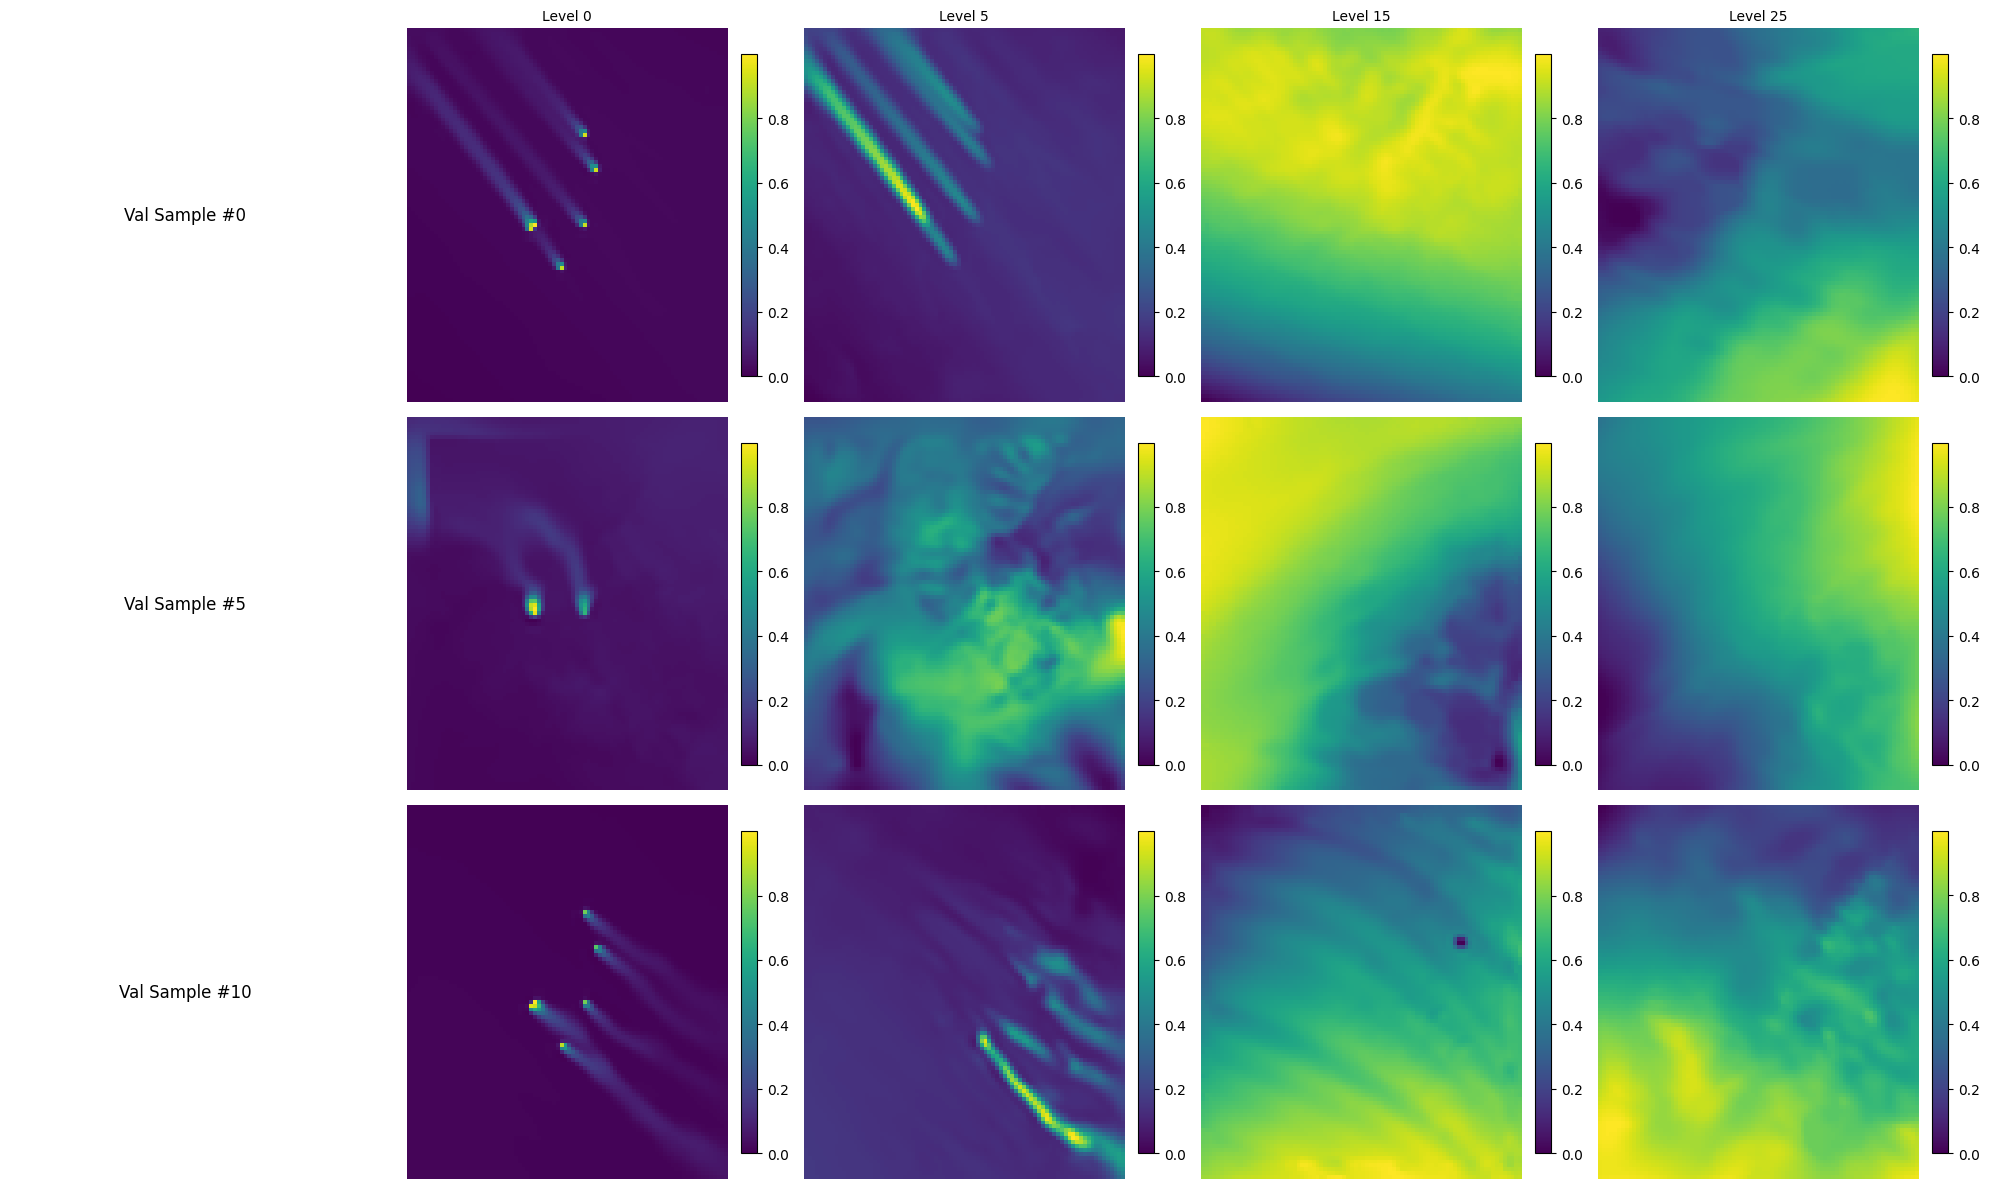

In [10]:
def plot_reconstruction(model, dataset, indices=[0, 1, 2], levels=[0, 10, 20, 30], device='cpu'):
    """Визуализация оригинала и реконструкции"""
    
    fig, axes = plt.subplots(len(indices), len(levels)+1, figsize=(20, 4*len(indices)))
    
    model.eval()
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            sample = dataset[idx].unsqueeze(0).to(device)
            reconstructed, _ = model(sample)
            
            original = sample.cpu().numpy()[0, 0]  # (32, 96, 84)
            recon = reconstructed.cpu().numpy()[0, 0]
            
            # Заголовок для строки
            axes[i, 0].text(0.5, 0.5, f'Val Sample #{idx}', 
                           ha='center', va='center', fontsize=12)
            axes[i, 0].axis('off')
            
            for j, level in enumerate(levels):
                if level < original.shape[0]:
                    if i == 0:
                        axes[i, j+1].set_title(f'Level {level}', fontsize=10)
                    
                    im = axes[i, j+1].imshow(original[level], cmap='viridis', aspect='auto')
                    axes[i, j+1].axis('off')
                    plt.colorbar(im, ax=axes[i, j+1], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.savefig('results/plots/reconstruction_examples.png', dpi=150)
    plt.show()


# Визуализация нескольких примеров из валидационной выборки
plot_reconstruction(model, val_dataset, indices=[0, 5, 10], levels=[0, 5, 15, 25], device=DEVICE)

## Анализ ошибок по высотам

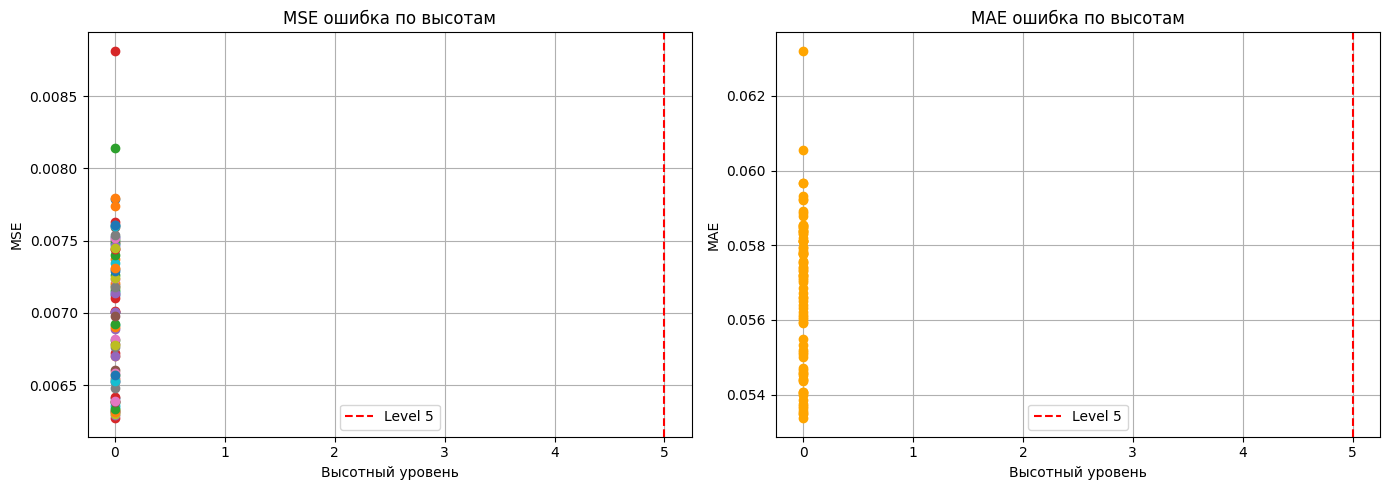


Статистика ошибок:
  Средний MSE (первые 5 уровней): 0.007015
  Средний MSE (остальные уровни): nan
  Средний MAE (первые 5 уровней): 0.056750
  Средний MAE (остальные уровни): nan


/tmp/ipykernel_1503405/2598446747.py:57: RuntimeWarning: Mean of empty slice.
  print(f"  Средний MSE (остальные уровни): {mse_height[5:].mean():.6f}")
/opt/tljh/user/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_1503405/2598446747.py:59: RuntimeWarning: Mean of empty slice.
  print(f"  Средний MAE (остальные уровни): {mae_height[5:].mean():.6f}")


In [11]:
def analyze_errors_by_height(model, dataset, device='cpu'):
    """Анализ MSE ошибки по каждому высотному уровню"""
    
    model.eval()
    mse_by_height = []
    mae_by_height = []
    
    with torch.no_grad():
        for i in range(len(dataset)):
            sample = dataset[i].unsqueeze(0).to(device)
            reconstructed, _ = model(sample)
            
            # MSE по высотам
            mse = (sample - reconstructed) ** 2
            mse_height = mse.mean(dim=(0, 2, 3)).cpu().numpy()
            mse_by_height.append(mse_height)
            
            # MAE по высотам
            mae = torch.abs(sample - reconstructed)
            mae_height = mae.mean(dim=(0, 2, 3)).cpu().numpy()
            mae_by_height.append(mae_height)
    
    mse_by_height = np.mean(mse_by_height, axis=0)
    mae_by_height = np.mean(mae_by_height, axis=0)
    
    return mse_by_height, mae_by_height


# Анализ
mse_height, mae_height = analyze_errors_by_height(model, val_dataset, device=DEVICE)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(mse_height, 'o-', linewidth=2)
axes[0].set_xlabel('Высотный уровень')
axes[0].set_ylabel('MSE')
axes[0].set_title('MSE ошибка по высотам')
axes[0].grid(True)
axes[0].axvline(x=5, color='r', linestyle='--', label='Level 5')
axes[0].legend()

axes[1].plot(mae_height, 'o-', color='orange', linewidth=2)
axes[1].set_xlabel('Высотный уровень')
axes[1].set_ylabel('MAE')
axes[1].set_title('MAE ошибка по высотам')
axes[1].grid(True)
axes[1].axvline(x=5, color='r', linestyle='--', label='Level 5')
axes[1].legend()

plt.tight_layout()
plt.savefig('results/plots/errors_by_height.png', dpi=150)
plt.show()

print(f"\nСтатистика ошибок:")
print(f"  Средний MSE (первые 5 уровней): {mse_height[:5].mean():.6f}")
print(f"  Средний MSE (остальные уровни): {mse_height[5:].mean():.6f}")
print(f"  Средний MAE (первые 5 уровней): {mae_height[:5].mean():.6f}")
print(f"  Средний MAE (остальные уровни): {mae_height[5:].mean():.6f}")

## Гистограмма распределения ошибок

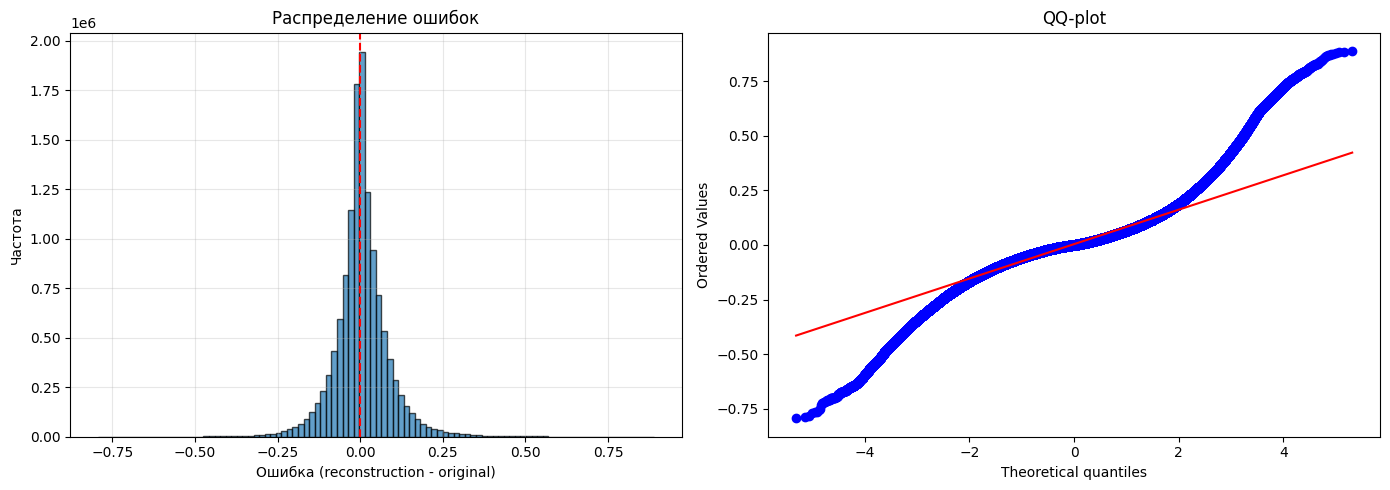


Статистика ошибок:
  Среднее: 0.004076
  Стандартное отклонение: 0.081690
  Медиана: 0.000488
  95-й перцентиль: 0.170842


In [12]:
def plot_error_distribution(model, dataset, device='cpu'):
    """Гистограмма распределения ошибок"""
    
    model.eval()
    all_errors = []
    
    with torch.no_grad():
        for i in range(min(len(dataset), 50)):  # Ограничим для скорости
            sample = dataset[i].unsqueeze(0).to(device)
            reconstructed, _ = model(sample)
            
            errors = (sample - reconstructed).cpu().numpy().flatten()
            all_errors.extend(errors)
    
    all_errors = np.array(all_errors)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Гистограмма
    axes[0].hist(all_errors, bins=100, alpha=0.7, edgecolor='black')
    axes[0].set_xlabel('Ошибка (reconstruction - original)')
    axes[0].set_ylabel('Частота')
    axes[0].set_title('Распределение ошибок')
    axes[0].axvline(x=0, color='r', linestyle='--')
    axes[0].grid(True, alpha=0.3)
    
    # QQ-plot
    from scipy import stats
    stats.probplot(all_errors, dist="norm", plot=axes[1])
    axes[1].set_title('QQ-plot')
    
    plt.tight_layout()
    plt.savefig('results/plots/error_distribution.png', dpi=150)
    plt.show()
    
    print(f"\nСтатистика ошибок:")
    print(f"  Среднее: {all_errors.mean():.6f}")
    print(f"  Стандартное отклонение: {all_errors.std():.6f}")
    print(f"  Медиана: {np.median(all_errors):.6f}")
    print(f"  95-й перцентиль: {np.percentile(np.abs(all_errors), 95):.6f}")


plot_error_distribution(model, val_dataset, device=DEVICE)

## Сводная таблица метрик на всей валидационной выборке

In [13]:
from torch.utils.data import DataLoader

val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
criterion = WeightedHeightLoss(alpha=1.0, beta=0.2, weight_first_5=5.0).to(DEVICE)

model.eval()
total_loss, total_mse, total_mae = 0, 0, 0
n_batches = 0

with torch.no_grad():
    for batch in val_loader:
        batch = batch.to(DEVICE)
        rec, _ = model(batch)
        loss, mse, mae = criterion(rec, batch)
        
        total_loss += loss.item()
        total_mse += mse.item()
        total_mae += mae.item()
        n_batches += 1

print("\n" + "="*50)
print("СВОДНАЯ ТАБЛИЦА МЕТРИК НА ВАЛИДАЦИИ")
print("="*50)
print(f"  Total Loss:  {total_loss/n_batches:.6f}")
print(f"  MSE:         {total_mse/n_batches:.6f}")
print(f"  MAE:         {total_mae/n_batches:.6f}")
print("="*50)

# Сравнение с сохранёнными значениями
print(f"\nСохранённые значения при обучении:")
print(f"  Best Val Loss: {checkpoint.get('best_val_loss', 'N/A')}")
print(f"  Best Val MSE: {checkpoint.get('best_val_mse', 'N/A')}")


СВОДНАЯ ТАБЛИЦА МЕТРИК НА ВАЛИДАЦИИ
  Total Loss:  0.008630
  MSE:         0.007015
  MAE:         0.056750

Сохранённые значения при обучении:
  Best Val Loss: 0.008629680797457694
  Best Val MSE: 0.007014723028987646
